Variance expliquée par composante :
[0.8885, 0.0616, 0.0258, 0.0131, 0.0074, 0.003, 0.0005, 0.0]
Shape original : (768, 8)
Shape après PCA : (768, 2)


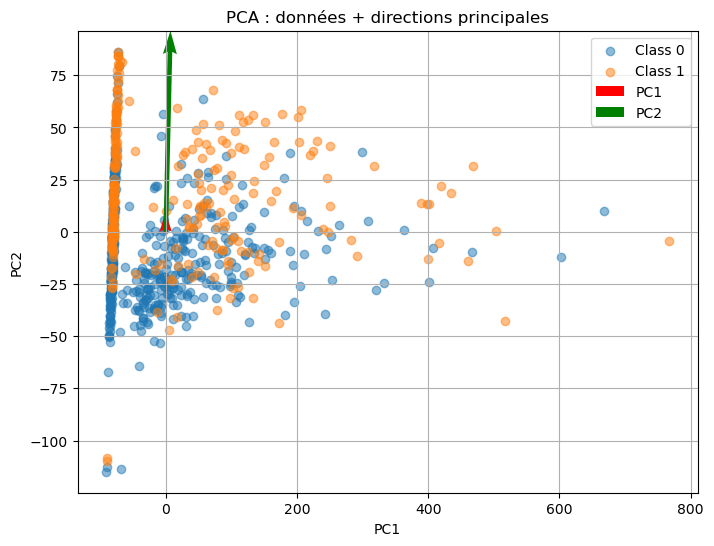

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger les données
data = pd.read_csv("../data/diabetes.csv")

# on enlève la colonne target (on fait PCA sur les features seulement)
X = data.drop(columns=[data.columns[-1]])

#  CENTRAGE DES DONNÉES
# on enlève la moyenne de chaque colonne
# pour que les données soient centrées autour de 0
X_centered = X - X.mean()


# MATRICE DE COVARIANCE
# on calcule comment les features varient ensemble
cov_matrix = np.cov(X_centered.T)


#  VALEURS PROPRES + VECTEURS PROPRES
# values = importance de chaque direction
# vectors = direction principale
values, vectors = np.linalg.eig(cov_matrix)


#  TRI DES COMPOSANTES
# on trie les valeurs propres du plus grand au plus petit
# car on veut garder les directions les plus importantes
idx = np.argsort(values)[::-1] # le -1 est pour inversé le sort de plus grand au plus petit

# on réorganise les valeurs propres selon l’ordre trouvé dans idx
# (du plus important au moins important)
values = values[idx]
# on réorganise les vecteurs propres de la même manière
# pour garder la correspondance entre chaque valeur propre et son vecteur
vectors = vectors[:, idx]


# VARIANCE EXPLIQUÉE
# on calcule combien d'information chaque composante garde
total_variance = sum(values)

explained_variance = [
    float(i / total_variance) for i in values
]

# affichage
print("Variance expliquée par composante :")
print([round(x, 4) for x in explained_variance])

# CHOIX DES COMPOSANTES
# ici on choisit 2 composantes principales 
n_components = 2

# on prend les vecteurs propres les plus importants
top_vectors = vectors[:, :n_components]

# PROJECTION DES DONNÉES
# on transforme les données originales
# en nouvelles variables (PC1, PC2)
X_pca = np.dot(X_centered, top_vectors)

# RESULTAT FINAL
print("Shape original :", X.shape)
print("Shape après PCA :", X_pca.shape)

# données projetées
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

y = data[data.columns[-1]]

plt.figure(figsize=(8,6))

# scatter des points
plt.scatter(pc1[y == 0], pc2[y == 0], label="Class 0", alpha=0.5)
plt.scatter(pc1[y == 1], pc2[y == 1], label="Class 1", alpha=0.5)

# VECTEURS PCA (directions)
origin = [0, 0]  # départ des flèches

# PC1 (premier vecteur)
plt.quiver(
    origin[0], origin[1],
    top_vectors[0, 0], top_vectors[1, 0],
    color="red", scale=3, label="PC1"
)

# PC2 (deuxième vecteur)
plt.quiver(
    origin[0], origin[1],
    top_vectors[0, 1], top_vectors[1, 1],
    color="green", scale=3, label="PC2"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA : données + directions principales")
plt.legend()

plt.grid()
plt.show()